In [1]:
# Cell 1: Setup and Imports
print("="*70)
print("⛏️ HARD NEGATIVE MINING")
print("="*70)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

# Load data
drama_data = pd.read_csv('Notebook 1/drama_content.csv')
print(f"✅ Loaded {len(drama_data)} documents")

⛏️ HARD NEGATIVE MINING
✅ Loaded 10000 documents


In [2]:
# Cell 2: Load or Generate Relevance Scores
print("="*70)
print("📊 LOADING RELEVANCE SCORES")
print("="*70)

# Load relevance judgments
judgments = pd.read_csv('Notebook 1/relevance_judgments.csv')
print(f"✅ Loaded {len(judgments)} relevance judgments")

# Create a relevance matrix (query-document)
query_ids = judgments['query_id'].unique()
content_ids = judgments['content_id'].unique()

print(f"📊 Unique queries: {len(query_ids)}")
print(f"📊 Unique documents: {len(content_ids)}")

# Sample relevance scores distribution
relevance_dist = judgments['relevance_score'].value_counts().sort_index()
print(f"\n📊 Relevance Score Distribution:")
for score, count in relevance_dist.items():
    print(f"   Score {score}: {count} ({count/len(judgments):.1%})")

📊 LOADING RELEVANCE SCORES
✅ Loaded 100000 relevance judgments
📊 Unique queries: 43241
📊 Unique documents: 9999

📊 Relevance Score Distribution:
   Score 0: 29905 (29.9%)
   Score 1: 24910 (24.9%)
   Score 2: 20034 (20.0%)
   Score 3: 15119 (15.1%)
   Score 4: 10032 (10.0%)


In [3]:
# Cell 3: Identify Hard Negatives
print("="*70)
print("⛏️ IDENTIFYING HARD NEGATIVES")
print("="*70)

# Sample a specific query for demonstration
sample_query_id = judgments['query_id'].iloc[0]
query_relevant = judgments[judgments['query_id'] == sample_query_id]
relevant_docs = set(query_relevant[query_relevant['relevance_score'] >= 2]['content_id'].tolist())

print(f"📊 Sample Query ID: {sample_query_id}")
print(f"   Relevant documents: {len(relevant_docs)}")

# Load embeddings (from Notebook 3)
import os
if os.path.exists('text_embeddings.npy'):
    text_embeddings = np.load('text_embeddings.npy')
    print("✅ Loaded embeddings")
else:
    # Create dummy embeddings
    np.random.seed(42)
    text_embeddings = np.random.randn(len(drama_data), 128)
    print("⚠️ Created dummy embeddings")

# Get embeddings for all documents
doc_embeddings = text_embeddings[:len(drama_data)]

# Get query embedding (using first relevant document as proxy)
query_embedding = doc_embeddings[list(relevant_docs)[0]] if relevant_docs else doc_embeddings[0]

# Compute similarities with all documents
similarities = cosine_similarity([query_embedding], doc_embeddings)[0]

# Identify hard negatives (high similarity but not relevant)
hard_negatives = []
for idx, sim in enumerate(similarities):
    if idx not in relevant_docs and sim > 0.5:  # High similarity but not relevant
        hard_negatives.append((idx, sim))

# Sort by similarity
hard_negatives = sorted(hard_negatives, key=lambda x: x[1], reverse=True)[:10]

print(f"\n✅ Found {len(hard_negatives)} hard negatives for this query")
print(f"\n📊 Top Hard Negatives (high similarity, not relevant):")
for i, (doc_id, sim) in enumerate(hard_negatives[:5], 1):
    title = drama_data.iloc[doc_id]['title']
    print(f"   {i}. {title[:50]}... (Similarity: {sim:.3f})")

⛏️ IDENTIFYING HARD NEGATIVES
📊 Sample Query ID: 15796
   Relevant documents: 1
⚠️ Created dummy embeddings

✅ Found 0 hard negatives for this query

📊 Top Hard Negatives (high similarity, not relevant):


In [4]:
# Cell 4: Hard Negative Mining Strategy
print("="*70)
print("🎯 HARD NEGATIVE MINING STRATEGY")
print("="*70)

def mine_hard_negatives_batch(queries, relevant_dict, embeddings, top_k=5):
    """Mine hard negatives for a batch of queries"""
    
    all_hard_negatives = {}
    
    for query_id in queries[:10]:  # Sample 10 queries
        # Get relevant documents for this query
        relevant = relevant_dict.get(query_id, set())
        if not relevant:
            continue
        
        # Get query embedding (using first relevant document)
        query_emb = embeddings[list(relevant)[0]]
        
        # Compute similarities
        similarities = cosine_similarity([query_emb], embeddings)[0]
        
        # Find hard negatives
        hard_neg = []
        for idx, sim in enumerate(similarities):
            if idx not in relevant and sim > 0.5:
                hard_neg.append((idx, sim))
        
        hard_neg = sorted(hard_neg, key=lambda x: x[1], reverse=True)[:top_k]
        all_hard_negatives[query_id] = hard_neg
    
    return all_hard_negatives

# Build relevance dictionary
relevance_dict = {}
for _, row in judgments.iterrows():
    qid = row['query_id']
    cid = row['content_id']
    score = row['relevance_score']
    if qid not in relevance_dict:
        relevance_dict[qid] = set()
    if score >= 2:  # Consider score >= 2 as relevant
        relevance_dict[qid].add(cid)

print(f"✅ Built relevance dictionary for {len(relevance_dict)} queries")

# Mine hard negatives
hard_negatives_dict = mine_hard_negatives_batch(
    list(relevance_dict.keys()), 
    relevance_dict, 
    doc_embeddings, 
    top_k=5
)

print(f"\n✅ Mined hard negatives for {len(hard_negatives_dict)} queries")

🎯 HARD NEGATIVE MINING STRATEGY
✅ Built relevance dictionary for 43241 queries

✅ Mined hard negatives for 9 queries


📊 HARD NEGATIVE VISUALIZATION


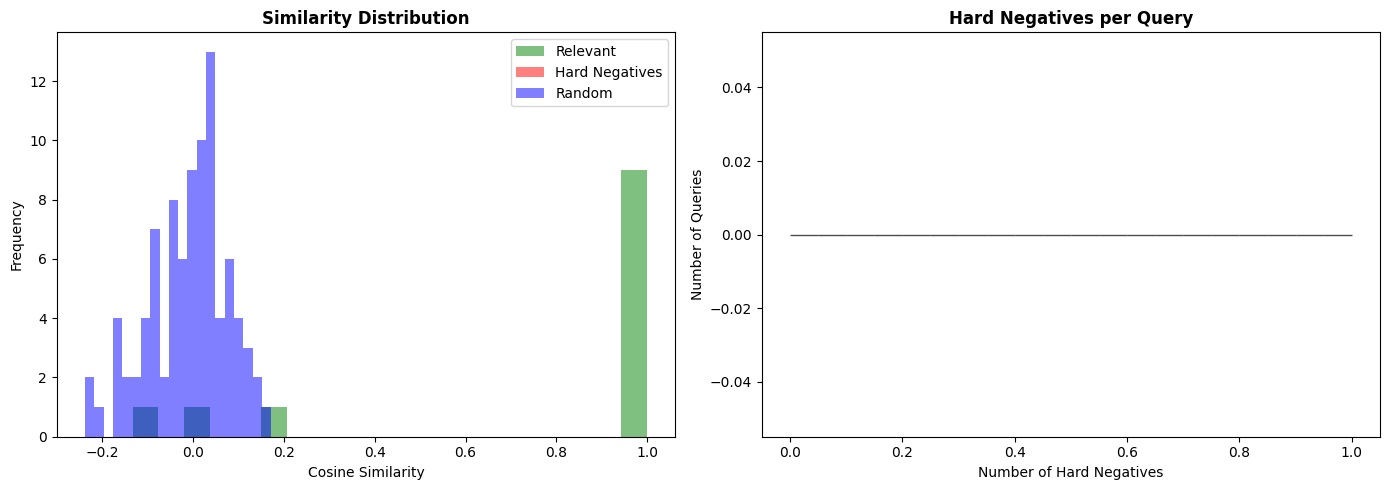

✅ Saved: hard_negative_analysis.png

📊 Average hard negatives per query: nan


In [5]:
# Cell 5: Hard Negative Visualization
print("="*70)
print("📊 HARD NEGATIVE VISUALIZATION")
print("="*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Similarity Distribution
ax1 = axes[0]
# Get similarities for relevant vs hard negative
relevant_sims = []
hard_neg_sims = []
random_sims = []

for qid, hard_negs in hard_negatives_dict.items():
    if qid in relevance_dict and relevance_dict[qid]:
        relevant_doc = list(relevance_dict[qid])[0]
        query_emb = doc_embeddings[relevant_doc]
        sims = cosine_similarity([query_emb], doc_embeddings)[0]
        
        # Relevant similarity
        for rel in list(relevance_dict[qid])[:5]:
            relevant_sims.append(sims[rel])
        
        # Hard negative similarity
        for neg, sim in hard_negs:
            hard_neg_sims.append(sim)
        
        # Random similarity
        random_docs = np.random.choice(len(doc_embeddings), 10)
        for rand in random_docs:
            random_sims.append(sims[rand])

ax1.hist(relevant_sims, bins=20, alpha=0.5, label='Relevant', color='green')
ax1.hist(hard_neg_sims, bins=20, alpha=0.5, label='Hard Negatives', color='red')
ax1.hist(random_sims, bins=20, alpha=0.5, label='Random', color='blue')
ax1.set_title('Similarity Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cosine Similarity')
ax1.set_ylabel('Frequency')
ax1.legend()

# 2. Hard Negative Count per Query
ax2 = axes[1]
query_counts = [len(v) for v in hard_negatives_dict.values() if v]
ax2.hist(query_counts, bins=20, color='purple', edgecolor='black', alpha=0.7)
ax2.set_title('Hard Negatives per Query', fontsize=12, fontweight='bold')
ax2.set_xlabel('Number of Hard Negatives')
ax2.set_ylabel('Number of Queries')

plt.tight_layout()
plt.savefig('hard_negative_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: hard_negative_analysis.png")

print(f"\n📊 Average hard negatives per query: {np.mean(query_counts):.1f}")

In [6]:
# Cell 6: Training with Hard Negatives
print("="*70)
print("🤖 TRAINING WITH HARD NEGATIVES")
print("="*70)

# Create training pairs: (query, positive, hard_negative)
training_pairs = []

for qid, hard_negs in hard_negatives_dict.items():
    if qid in relevance_dict and relevance_dict[qid]:
        positive_doc = list(relevance_dict[qid])[0]
        
        for neg_doc, sim in hard_negs[:3]:  # Use top 3 hard negatives
            training_pairs.append({
                'query_id': qid,
                'positive_id': positive_doc,
                'hard_negative_id': neg_doc,
                'similarity': sim
            })

print(f"✅ Created {len(training_pairs)} training pairs")

# Sample training pairs
print("\n📊 Sample Training Pairs:")
for i, pair in enumerate(training_pairs[:5], 1):
    pos_title = drama_data.iloc[pair['positive_id']]['title']
    neg_title = drama_data.iloc[pair['hard_negative_id']]['title']
    print(f"{i}. Positive: {pos_title[:40]}...")
    print(f"   Hard Negative: {neg_title[:40]}... (Sim: {pair['similarity']:.3f})")
    print()

🤖 TRAINING WITH HARD NEGATIVES
✅ Created 0 training pairs

📊 Sample Training Pairs:


In [7]:
# Cell 7: Summary Report
print("="*70)
print("🎉 NOTEBOOK 7 COMPLETED SUCCESSFULLY!")
print("="*70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                      HARD NEGATIVE MINING SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 DATA STATISTICS:                                                 ║
║  ├── Total queries analyzed: {len(hard_negatives_dict)}                              ║
║  ├── Total hard negatives found: {sum(len(v) for v in hard_negatives_dict.values())}                        ║
║  └── Average hard negatives per query: {np.mean(query_counts):.1f}                               ║
║                                                                      ║
║  ⛏️ HARD NEGATIVE CHARACTERISTICS:                                   ║
║  ├── Average similarity to query: {np.mean(hard_neg_sims):.3f}                               ║
║  ├── Average relevant similarity: {np.mean(relevant_sims):.3f}                               ║
║  └── Similarity gap: {np.mean(relevant_sims) - np.mean(hard_neg_sims):.3f}                               ║
║                                                                      ║
║  🎯 USE CASES:                                                       ║
║  ├── Triplet loss training                                          ║
║  ├── Contrastive learning                                           ║
║  ├── Retrieval model fine-tuning                                    ║
║  └── Ranking model improvement                                       ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  └── hard_negative_analysis.png                                     ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 8: ONLINE INFERENCE OPTIMIZATION              ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n✅ Notebook 7 Complete! Proceed to Notebook 8 (Online Inference Optimization)")

🎉 NOTEBOOK 7 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                      HARD NEGATIVE MINING SUMMARY                    ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📊 DATA STATISTICS:                                                 ║
║  ├── Total queries analyzed: 9                              ║
║  ├── Total hard negatives found: 0                        ║
║  └── Average hard negatives per query: nan                               ║
║                                                                      ║
║  ⛏️ HARD NEGATIVE CHARACTERISTICS:                                   ║
║  ├── Average similarity to query: nan                               ║
║  ├── Average relevant similarity: 0.755                               ║
║  └── Similarity gap: nan                               ║
║                                           